# Generate FLUKA input files for T2R and leNuSTORM ring simulation

Generate the FLUKA files for the Pion Transfer line and LEnuSTORM Ring

Uses:
- essbeamsim.py 
- essbeamsim_plots.py
- essbeamsim.yaml

Needs:
Xsuite installation from : https://xsuite.readthedocs.io/en/latest/

Status: 
12.11.2025 : code completed up to the generation of the beam (TR2 and NUSTORM) elements.
        
To do:
- generate the global volumes of the tunnels etc. 

In [167]:
import numpy as np
import pandas as pd

import xobjects as xo
import xtrack as xt

import math

import matplotlib 
import matplotlib.pyplot as plt
import matplotlib.patches as patches


import re
import json
import yaml, pprint
# from dotdict import DotDict as dd


import essbeamsim as bsim
import essbeamsim_plots as bplot

import scipy
import scipy.constants

from particle import Particle

print(f' Beam parameters : ')
import os

%run ../InitPlots.py
    
MyPlots().configPlots('')

print_array_with_format = lambda x : ' '.join(f'{v:.5f}' for v in x)
distance2d = lambda x,y : np.sqrt((x[0]-y[0])**2 + (x[1]-y[1])**2)

getcoord = lambda x, ofs: ' '.join(map(str, (np.array(x)+ofs*np.sign(x))*100))


 Beam parameters : 

>>> Running InitPlots.py - Version : 1.02 - 07.03.2023 (IE)
---- running configPlots function 


In [168]:
with open('essbeamsim.yaml','r') as fin:
    config = bsim.DotDict(yaml.safe_load(fin))
pprint.pprint(config)

{'beam_size': 0.1,
 'd1_aperture_margin': 1.2,
 'd_shield': 4.0,
 'h_decay_tunnel': [-6.5, 6.5],
 'h_ring_tunnel': 4,
 'h_target_cavern': [-3.5, 3.5],
 'h_tline_tunnel': 4,
 'l_decay_tunnel': 60,
 'magnet_width': 0.8,
 'mparking_radious': 10,
 'mparking_start': [0, 0, -101],
 'qaperture_x': 0.15,
 'qaperture_y': 0.15,
 'r_decay_pipe': 2.5,
 'ring_walls': 2,
 'ss_to_lemmond': 50,
 't2r': {'l_bend_end': 0.35,
         'l_bend_woke': 0.5,
         'l_qfl_end': 0.2,
         'l_qfl_h': 0.9,
         'l_qfl_w': 0.9,
         'l_quad_end': 0.2,
         'l_quad_h': 0.6,
         'l_quad_w': 0.6,
         'l_vac': 0.1},
 't2r_start': [0, 2.0],
 't2rend_to_inj': [-2, 6.0],
 't2rstart_to_inj': [-9.08278251237319, 23.1539181004073],
 't_tline_tunnel': 2,
 'target_len': 0.78,
 'target_radious': 0.015,
 'thbox_x': [-1, 1],
 'thbox_y': [-1, 1],
 'thbox_z': [-0.1, 1],
 'trg_to_lblnd': 320,
 'w_decay_tunnel': [-7, 7],
 'w_ring_tunnel': 2,
 'w_target_cavern': [-3.5, 3.5],
 'w_tline_tunnel': 5,
 'z_tar

## Reminder on Beam Parameters

Reminder on beam energy and momentum

$E = E_{kin} + E_0(=\mathrm{m}_0\, c^2)$

$E^2 = E_0^2 + P^2 \Rightarrow P^2 = \sqrt{E^2 - E_0^2} \Rightarrow P = \sqrt{(E-E_0)(E+E_0)}$

$P = \sqrt{E_{kin}(E_{kin}+2E_0)}$

$\beta\gamma = P/\mathrm{m}_0$

$\gamma = \sqrt{(\beta\gamma)^2+1}$

$\beta = \beta\gamma/\gamma$

In [169]:
pion = Particle.from_name('pi+')
muon = Particle.from_name('mu+')
proton = Particle.from_name('p')

# particle mass [MeV/c2] --> convert to [GeV/c2]
pmass_gev = proton.mass/1000
pimass_gev = pion.mass/1000
mumass_gev = muon.mass/1000

# print(xx.mass, xx.lifetime*1.0e-9)

# primary proton beam
pbeam_ekk_gev = 2.5
pbeam_etot = pbeam_ekk_gev + pmass_gev
pbeam_mom_gev = np.sqrt(pbeam_ekk_gev*(pbeam_ekk_gev+2*pmass_gev))
pbeam_beta, pbeam_gamma = bsim.particle_beta_gamma('p', pbeam_mom_gev)

# pion beam
beam_momentum = 0.7
pion_beta, pion_gamma = bsim.particle_beta_gamma('pi+', beam_momentum)
pion_decay_length = pion.lifetime*1.0e-9*scipy.constants.c*pion_gamma

# muon beam
muon_momentum = 0.4
muon_beta, muon_gamma = bsim.particle_beta_gamma('mu+', muon_momentum)
muon_lifetime = muon.lifetime*1.0e-9*muon_gamma  # lifetime is given in ns
muon_decay_length = muon_lifetime*scipy.constants.c

muon_momentum_max = 0.7
muon_beta_max, muon_gamma_max = bsim.particle_beta_gamma('mu+', muon_momentum_max)
muon_lifetime_max = muon.lifetime*1.0e-9*muon_gamma_max  # lifetime is given in ns
muon_decay_length_max = muon_lifetime_max*scipy.constants.c

print(f''' Paramters (units in GeV)
            primary proton beam:
                {pbeam_ekk_gev=}
                {pbeam_etot=:.5f}
                {pbeam_mom_gev=:.5f}
                {pbeam_gamma=:.5f}
                {pbeam_beta=:.5f}
            extracted pion beam:
                {beam_momentum=}
                {pion_gamma=:.5f} [s]
                {pion_decay_length=:.5f} [m]
            stored muon beam:
                {muon_momentum=}
                {muon_beta=:.5f}
                {muon_gamma=:.5f}
                {muon_lifetime=:.5f} [s], {muon_lifetime/1.0e-6:.5f} [us]
                {muon_decay_length=:.5f} [m]
                
                {muon_momentum_max=}
                {muon_beta_max=:.5f}
                {muon_gamma_max=:.5f}
                {muon_lifetime_max=:.5f} [s], {muon_lifetime_max/1.0e-6:.5f} [us]
                {muon_decay_length_max=:.5f} [m]
        ''')

 Paramters (units in GeV)
            primary proton beam:
                pbeam_ekk_gev=2.5
                pbeam_etot=3.43827
                pbeam_mom_gev=3.30777
                pbeam_gamma=3.66447
                pbeam_beta=0.96205
            extracted pion beam:
                beam_momentum=0.7
                pion_gamma=5.11411 [s]
                pion_decay_length=39.91268 [m]
            stored muon beam:
                muon_momentum=0.4
                muon_beta=0.96684
                muon_gamma=3.91563
                muon_lifetime=0.00001 [s], 8.60257 [us]
                muon_decay_length=2578.98569 [m]
                
                muon_momentum_max=0.7
                muon_beta_max=0.98880
                muon_gamma_max=6.70017
                muon_lifetime_max=0.00001 [s], 14.72015 [us]
                muon_decay_length_max=4412.98966 [m]
        


## Load the LEnuSTORM lattice

In [170]:

def get_kvalue(r):
    if r.element_type == 'Bend':
        return r.element.k0
    elif r.element_type == 'Quadrupole' :
        return r.element.k1
    else:
        return 0
    
def get_flukadf(df, lineid='TL', verbose=False):
    ''' Prepare the beam elements DF for FLUKA'''

    df['length'] = df['s_end'] - df['s_start']
    df['kvalue'] = df.apply(lambda x: get_kvalue(x), axis=1)

    mask = ((df.element_type != 'Drift') & (df.kvalue != 0)) | (df.element_type == 'Marker')

    df = df[mask].copy()
    
    df['length_cm'] = df['length'].apply(lambda x: x*100)
    df['X_cm']      = df['X'].apply(lambda x: x*100)
    df['Y_cm']      = df['Y'].apply(lambda x: x*100)
    df['Z_cm']      = df['Z'].apply(lambda x: x*100)
    df['theta_deg'] = df['theta'].apply(lambda x: x*180/np.pi)
    
    df['belement'] = lineid + df["name"].str[:2] + (df.groupby(df["name"].str[:2]).cumcount() + 1).astype(str)
    df['model'] = np.select(
        [
            df['element_type'] == 'Bend',
            df['element_type'] == 'Quadrupole'
        ],
        [
            'MB' + (df['length'] * 100).round().astype(int).astype(str),
            'QM' + (df['length'] * 100).round().astype(int).astype(str)
        ],
        default= np.nan
        )
    if verbose:
        mask = df.element_type.isin(['Bend', 'Quadrupole'])
        print(f' -- belements: {set(df["belement"][mask].unique())}')
        print(f' -- models: {set(df["model"][mask].unique())}')

    return df

In [171]:
# fin = '../src/ring-mb3.json'
fin = '../src/one-alternating-bend_ring600.json'
nustormring = xt.Line.from_json(fin)

add_inj_marker = False
if add_inj_marker : 
    env = nustormring.env
    env.new('t2rinj', xt.Marker)

    # --- add injection marker
    nustormring.insert([
        env.place('t2rinj', at=100.325)
    ])

    # --- cycle the ring to start from a given element
    nustormring.cycle(name_first_element='t2rinj', inplace=True)

nustormring_df = nustormring.to_pandas()

ringsrv_df = nustormring.survey().to_pandas()
ringsrv_df = ringsrv_df.rename(columns={'name':'name_srv'})
display(ringsrv_df.head(20))

nustormring_df = nustormring_df.join(ringsrv_df[['name_srv','X','Y','Z','theta','phi','psi','angle']], how='outer')
assert nustormring_df.isna().any().any(), 'NaN values found in the dataframe' # there should be no NaN if dataframes of same length

nustormring_elements_df = get_flukadf(nustormring_df, lineid='NS', verbose=True)
display(nustormring_elements_df.head(20))

Loading line from dict:   0%|          | 0/52 [00:00<?, ?it/s]

Done loading line from dict.           


,X,Y,Z,theta,phi,psi,ex,ey,ez,p0,...,drift_length,length,angle,rot_s_rad,ref_shift_x,ref_shift_y,ref_rot_x_rad,ref_rot_y_rad,ref_rot_s_rad,s
0,0.0,0.0,0.000,0.0,0.0,0.0,"[1.0, 0.0, -0.0]","[-0.0, 1.0, 0.0]","[0.0, 0.0, 1.0]","[0.0, 0.0, 0.0]",...,0.000,0.000,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.000
1,0.0,0.0,0.000,0.0,0.0,0.0,"[1.0, 0.0, -0.0]","[-0.0, 1.0, 0.0]","[0.0, 0.0, 1.0]","[0.0, 0.0, 0.0]",...,0.125,0.125,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.000
2,0.0,0.0,0.125,0.0,0.0,0.0,"[1.0, 0.0, -0.0]","[-0.0, 1.0, 0.0]","[0.0, 0.0, 1.0]","[0.0, 0.0, 0.125]",...,1.300,1.300,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.125
3,0.0,0.0,1.425,0.0,0.0,0.0,"[1.0, 0.0, -0.0]","[-0.0, 1.0, 0.0]","[0.0, 0.0, 1.0]","[0.0, 0.0, 1.425]",...,0.250,0.250,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,1.425
4,0.0,0.0,1.675,0.0,0.0,0.0,"[1.0, 0.0, -0.0]","[-0.0, 1.0, 0.0]","[0.0, 0.0, 1.0]","[0.0, 0.0, 1.675]",...,1.300,1.300,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,1.675
5,0.0,0.0,2.975,0.0,0.0,0.0,"[1.0, 0.0, -0.0]","[-0.0, 1.0, 0.0]","[0.0, 0.0, 1.0]","[0.0, 0.0, 2.975]",...,0.250,0.250,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,2.975
6,0.0,0.0,3.225,0.0,0.0,0.0,"[1.0, 0.0, -0.0]","[-0.0, 1.0, 0.0]","[0.0, 0.0, 1.0]","[0.0, 0.0, 3.225]",...,1.300,1.300,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,3.225
7,0.0,0.0,4.525,0.0,0.0,0.0,"[1.0, 0.0, -0.0]","[-0.0, 1.0, 0.0]","[0.0, 0.0, 1.0]","[0.0, 0.0, 4.525]",...,0.250,0.250,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,4.525
8,0.0,0.0,4.775,0.0,0.0,0.0,"[1.0, 0.0, -0.0]","[-0.0, 1.0, 0.0]","[0.0, 0.0, 1.0]","[0.0, 0.0, 4.775]",...,1.300,1.300,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,4.775
9,0.0,0.0,6.075,0.0,0.0,0.0,"[1.0, 0.0, -0.0]","[-0.0, 1.0, 0.0]","[0.0, 0.0, 1.0]","[0.0, 0.0, 6.075]",...,0.250,0.250,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,6.075


 -- belements: {'NSQD77', 'NSQF61', 'NSQD61', 'NSQF136', 'NSQF33', 'NSQD48', 'NSQD83', 'NSQF25', 'NSQF36', 'NSQD60', 'NSQF115', 'NSQF110', 'NSQD114', 'NSQD113', 'NSQD14', 'NSQD128', 'NSQD62', 'NSQF120', 'NSQF11', 'NSQD82', 'NSQD78', 'NSQD56', 'NSQF18', 'NSQF62', 'NSQD95', 'NSQD88', 'NSQD13', 'NSQD100', 'NSQD32', 'NSQD31', 'NSQD116', 'NSQD51', 'NSQD79', 'NSB.12', 'NSQD21', 'NSB.13', 'NSQF116', 'NSQF48', 'NSQF124', 'NSQD65', 'NSQF134', 'NSQF141', 'NSQF42', 'NSQF47', 'NSQF111', 'NSQF35', 'NSQD135', 'NSQF70', 'NSQF65', 'NSB.10', 'NSQF13', 'NSQF14', 'NSQF78', 'NSQD44', 'NSQF87', 'NSQD85', 'NSQF95', 'NSQF9', 'NSQD8', 'NSQD57', 'NSQD136', 'NSQD2', 'NSQD10', 'NSQF41', 'NSQD17', 'NSQD76', 'NSQF31', 'NSQD26', 'NSQD74', 'NSQF84', 'NSQD101', 'NSQF144', 'NSQD109', 'NSQF104', 'NSQF58', 'NSQF73', 'NSQD25', 'NSQF38', 'NSQF107', 'NSQF109', 'NSQD38', 'NSQF54', 'NSQF69', 'NSQF81', 'NSB.8', 'NSB.9', 'NSQF74', 'NSQF91', 'NSQF123', 'NSQF131', 'NSQD72', 'NSQD138', 'NSQD90', 'NSQD131', 'NSQF2', 'NSQF93', 'NSQ

,s,element_type,name,isthick,isreplica,parent_name,iscollective,element,s_start,s_center,...,angle,length,kvalue,length_cm,X_cm,Y_cm,Z_cm,theta_deg,belement,model
0,0.000,Marker,RING_ORIGIN,False,False,None,False,Marker(),0.000,0.0000,...,0.0,0.000,0.000000,0.0,0.0,0.0,0.0,0.0,NSRI1,NaN
1,0.000,Quadrupole,QF.A,True,False,None,False,"Quadrupole(k1=2.19, k1s=0, length=0.125, num_m...",0.000,0.0625,...,0.0,0.125,2.194177,12.5,0.0,0.0,0.0,0.0,NSQF1,QM12
3,1.425,Quadrupole,QD.M2,True,False,None,False,"Quadrupole(k1=-2.09, k1s=0, length=0.25, num_m...",1.425,1.5500,...,0.0,0.250,-2.089355,25.0,0.0,0.0,142.5,0.0,NSQD1,QM25
5,2.975,Quadrupole,QF.M1,True,False,None,False,"Quadrupole(k1=2.31, k1s=0, length=0.25, num_mu...",2.975,3.1000,...,0.0,0.250,2.307367,25.0,0.0,0.0,297.5,0.0,NSQF2,QM25
7,4.525,Quadrupole,QD.M1,True,False,None,False,"Quadrupole(k1=-2.42, k1s=0, length=0.25, num_m...",4.525,4.6500,...,0.0,0.250,-2.419313,25.0,0.0,0.0,452.5,0.0,NSQD2,QM25
9,6.075,Quadrupole,QF.M0,True,False,None,False,"Quadrupole(k1=2.92, k1s=0, length=0.25, num_mu...",6.075,6.2000,...,0.0,0.250,2.916284,25.0,0.0,0.0,607.5,0.0,NSQF3,QM25
11,7.625,Quadrupole,QD.M0,True,False,None,False,"Quadrupole(k1=-2.97, k1s=0, length=0.25, num_m...",7.625,7.7500,...,0.0,0.250,-2.971037,25.0,0.0,0.0,762.5,0.0,NSQD3,QM25
13,9.175,Quadrupole,QF.S,True,False,None,False,"Quadrupole(k1=3.31, k1s=0, length=0.125, num_m...",9.175,9.2375,...,0.0,0.125,3.311778,12.5,0.0,0.0,917.5,0.0,NSQF4,QM12
14,9.300,Marker,matching_start,False,False,None,False,Marker(),9.300,9.3000,...,0.0,0.000,0.000000,0.0,0.0,0.0,930.0,0.0,NSma1,NaN
15,9.300,Marker,start_cell.S.ShFoDo0,False,False,None,False,Marker(),9.300,9.3000,...,0.0,0.000,0.000000,0.0,0.0,0.0,930.0,0.0,NSst1,NaN


In [172]:
if 0 : 
    _nustormtbl = nustormring.get_table()
    print(_nustormtbl.cols)
    # _nustormtbl.show()
    _nustormtbl.rows[_nustormtbl.element_type=='Bend']


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


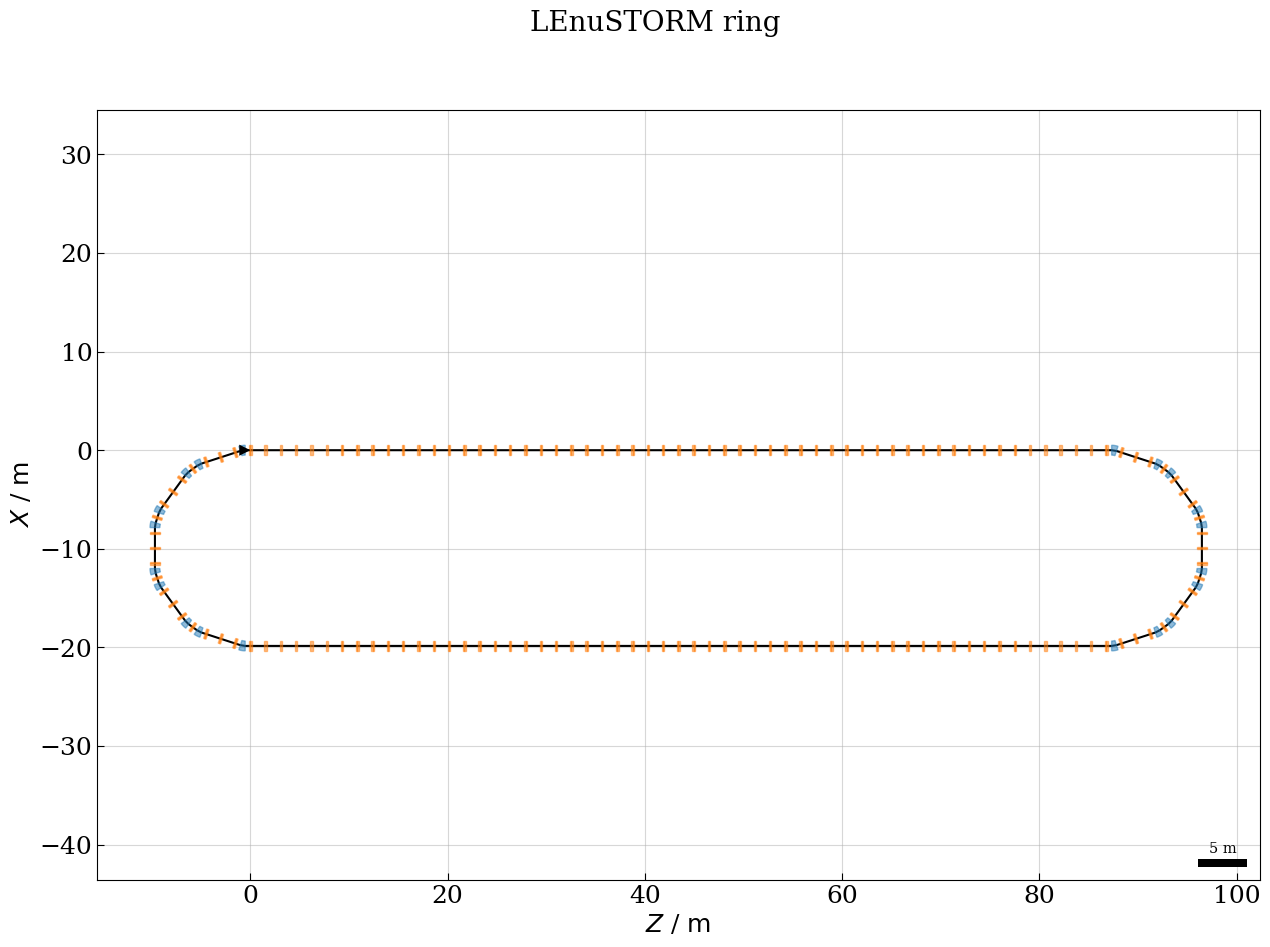

In [173]:
if True:
    import xplt
    plot = xplt.FloorPlot(nustormring.survey(), figsize=(15,10))
    plot.add_scale()
    plot.title('LEnuSTORM ring ')
    plot.ax.set(ylim=(-10, 1))
    
    # plot2 = xplt.KnlPlot(nustormring, figsize=(7, 3))
    # plot2.ax.set(ylim=(-1, 1));
    
    

## Load the T2R beam transfer line

In [174]:
# fin = '../src/transfer-line-1050.json'
fin = '../src/20250922-t2r-line.json'
t2rline = xt.Line.from_json(fin)

_t2renv = t2rline.env
_t2renv.new('t2rend', xt.Marker)
t2rline.insert([
    _t2renv.place('t2rend', at=t2rline.get_length())
    ])

t2rline_df = t2rline.to_pandas()
t2rline_df['length'] = t2rline_df['s_end'] - t2rline_df['s_start']
    
t2rline_df['kvalue'] = t2rline_df.apply(lambda x: get_kvalue(x), axis=1)

t2rsrv_df = t2rline.survey().to_pandas()
t2rsrv_df = t2rsrv_df.rename(columns={'name':'name_srv'})
display(t2rsrv_df[t2rsrv_df.element_type != 'Drift'].head(40))

t2rline_df = t2rline_df.join(t2rsrv_df[['name_srv','X','Y','Z','theta','phi','psi','angle']], how='outer')
assert t2rline_df.isna().any().any(), 'NaN values found in the dataframe' # there should be no NaN if dataframes of same length

t2rline_elements_df = get_flukadf(t2rline_df, lineid='TL', verbose=True)

display(t2rline_elements_df.head())

Loading line from dict:   0%|          | 0/32 [00:00<?, ?it/s]

Done loading line from dict.           


Slicing line:   0%|          | 0/31 [00:00<?, ?it/s]

,X,Y,Z,theta,phi,psi,ex,ey,ez,p0,...,drift_length,length,angle,rot_s_rad,ref_shift_x,ref_shift_y,ref_rot_x_rad,ref_rot_y_rad,ref_rot_s_rad,s
0,0.000000,0.0,0.000000,0.000000,0.0,0.0,"[1.0, 0.0, -0.0]","[-0.0, 1.0, 0.0]","[0.0, 0.0, 1.0]","[0.0, 0.0, 0.0]",...,1.500000,1.500000,0.428280,0.0,0.0,0.0,0.0,-0.0,0.0,0.000000
2,-0.523984,0.0,1.909403,-0.428280,0.0,0.0,"[0.9096813403136949, 0.0, 0.41530694562585835]","[0.0, 1.0, 0.0]","[-0.41530694562585835, 0.0, 0.9096813403136949]","[-0.5239837401250507, 0.0, 1.9094034103779414]",...,0.800000,0.800000,0.000000,0.0,0.0,0.0,0.0,-0.0,0.0,2.000000
4,-1.063883,0.0,3.091989,-0.428280,0.0,0.0,"[0.9096813403136949, 0.0, 0.41530694562585835]","[0.0, 1.0, 0.0]","[-0.41530694562585835, 0.0, 0.9096813403136949]","[-1.0638827694386668, 0.0, 3.0919891527857453]",...,0.800000,0.800000,0.000000,0.0,0.0,0.0,0.0,-0.0,0.0,3.300000
6,-1.603782,0.0,4.274575,-0.428280,0.0,0.0,"[0.9096813403136949, 0.0, 0.41530694562585835]","[0.0, 1.0, 0.0]","[-0.41530694562585835, 0.0, 0.9096813403136949]","[-1.6037817987522827, 0.0, 4.274574895193549]",...,0.800000,0.800000,0.000000,0.0,0.0,0.0,0.0,-0.0,0.0,4.600000
8,-2.143681,0.0,5.457161,-0.428280,0.0,0.0,"[0.9096813403136949, 0.0, 0.41530694562585835]","[0.0, 1.0, 0.0]","[-0.41530694562585835, 0.0, 0.9096813403136949]","[-2.1436808280658988, 0.0, 5.457160637601352]",...,1.500000,1.500000,0.428280,0.0,0.0,0.0,0.0,-0.0,0.0,5.900000
10,-3.496608,0.0,7.048692,-0.856560,0.0,0.0,"[0.6550402818298406, 0.0, 0.7555939578770352]","[0.0, 1.0, 0.0]","[-0.7555939578770352, 0.0, 0.6550402818298406]","[-3.4966075442158435, 0.0, 7.048692375272823]",...,0.800000,0.800000,0.000000,0.0,0.0,0.0,0.0,-0.0,0.0,8.010218
12,-4.259922,0.0,7.710426,-0.856560,0.0,0.0,"[0.6550402818298406, 0.0, 0.7555939578770352]","[0.0, 1.0, 0.0]","[-0.7555939578770352, 0.0, 0.6550402818298406]","[-4.259922093103921, 0.0, 7.710425799707954]",...,0.800000,0.800000,0.000000,0.0,0.0,0.0,0.0,-0.0,0.0,9.020436
14,-5.023237,0.0,8.372159,-0.856560,0.0,0.0,"[0.6550402818298406, 0.0, 0.7555939578770352]","[0.0, 1.0, 0.0]","[-0.7555939578770352, 0.0, 0.6550402818298406]","[-5.023236641991998, 0.0, 8.372159224143083]",...,0.800000,0.800000,0.000000,0.0,0.0,0.0,0.0,-0.0,0.0,10.030654
16,-5.786551,0.0,9.033893,-0.856560,0.0,0.0,"[0.6550402818298406, 0.0, 0.7555939578770352]","[0.0, 1.0, 0.0]","[-0.7555939578770352, 0.0, 0.6550402818298406]","[-5.7865511908800755, 0.0, 9.033892648578213]",...,0.800000,0.800000,0.000000,0.0,0.0,0.0,0.0,-0.0,0.0,11.040872
18,-6.700985,0.0,9.826634,-0.856560,0.0,0.0,"[0.6550402818298406, 0.0, 0.7555939578770352]","[0.0, 1.0, 0.0]","[-0.7555939578770352, 0.0, 0.6550402818298406]","[-6.700984531343559, 0.0, 9.826634129379311]",...,0.800000,0.800000,0.000000,0.0,0.0,0.0,0.0,-0.0,0.0,12.251090


 -- belements: {'TLmq10', 'TLmb2', 'TLmb3', 'TLmb1', 'TLmq3', 'TLmq8', 'TLmq6', 'TLmq11', 'TLmq9', 'TLmb4', 'TLmq1', 'TLmq7', 'TLmq5', 'TLmq2', 'TLmq4'}
 -- models: {'MB138', 'QM80', 'MB150'}


,s,element_type,name,isthick,isreplica,parent_name,iscollective,element,s_start,s_center,...,phi,psi,angle,length_cm,X_cm,Y_cm,Z_cm,theta_deg,belement,model
0,0.0,Bend,mbtl0.0,True,False,None,False,"Bend(length=1.5, k0=0.286, k1=0, h=0.286, k0_f...",0.0,0.75,...,0.0,0.0,0.42828,150.0,0.000000,0.0,0.000000,0.000000,TLmb1,MB150
2,2.0,Quadrupole,mq_t2r.0,True,False,None,False,"Quadrupole(k1=-0.801, k1s=0, length=0.8, num_m...",2.0,2.40,...,0.0,0.0,0.00000,80.0,-52.398374,0.0,190.940341,-24.538648,TLmq1,QM80
4,3.3,Quadrupole,mq_t2r.1,True,False,None,False,"Quadrupole(k1=1.4, k1s=0, length=0.8, num_mult...",3.3,3.70,...,0.0,0.0,0.00000,80.0,-106.388277,0.0,309.198915,-24.538648,TLmq2,QM80
6,4.6,Quadrupole,mq_t2r.2,True,False,None,False,"Quadrupole(k1=-0.801, k1s=0, length=0.8, num_m...",4.6,5.00,...,0.0,0.0,0.00000,80.0,-160.378180,0.0,427.457490,-24.538648,TLmq3,QM80
8,5.9,Bend,mbtl0.1,True,False,None,False,"Bend(length=1.5, k0=0.286, k1=0, h=0.286, k0_f...",5.9,6.65,...,0.0,0.0,0.42828,150.0,-214.368083,0.0,545.716064,-24.538648,TLmb2,MB150


In [175]:
t2rline_elements_df.belement

0      TLmb1
2      TLmq1
4      TLmq2
6      TLmq3
8      TLmb2
10     TLmq4
12     TLmq5
14     TLmq6
16     TLmq7
18     TLmq8
20     TLen1
21     TLmb3
23     TLmq9
25    TLmq10
27    TLmq11
29     TLmb4
31     TLt21
Name: belement, dtype: object

In [176]:
t2rline_elements_df[['belement','kvalue']]

,belement,kvalue
0,TLmb1,0.285520
2,TLmq1,-0.800591
4,TLmq2,1.399934
6,TLmq3,-0.800591
8,TLmb2,0.285520
10,TLmq4,1.411869
12,TLmq5,-1.964204
14,TLmq6,3.467155
16,TLmq7,-1.837422
18,TLmq8,1.691994


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


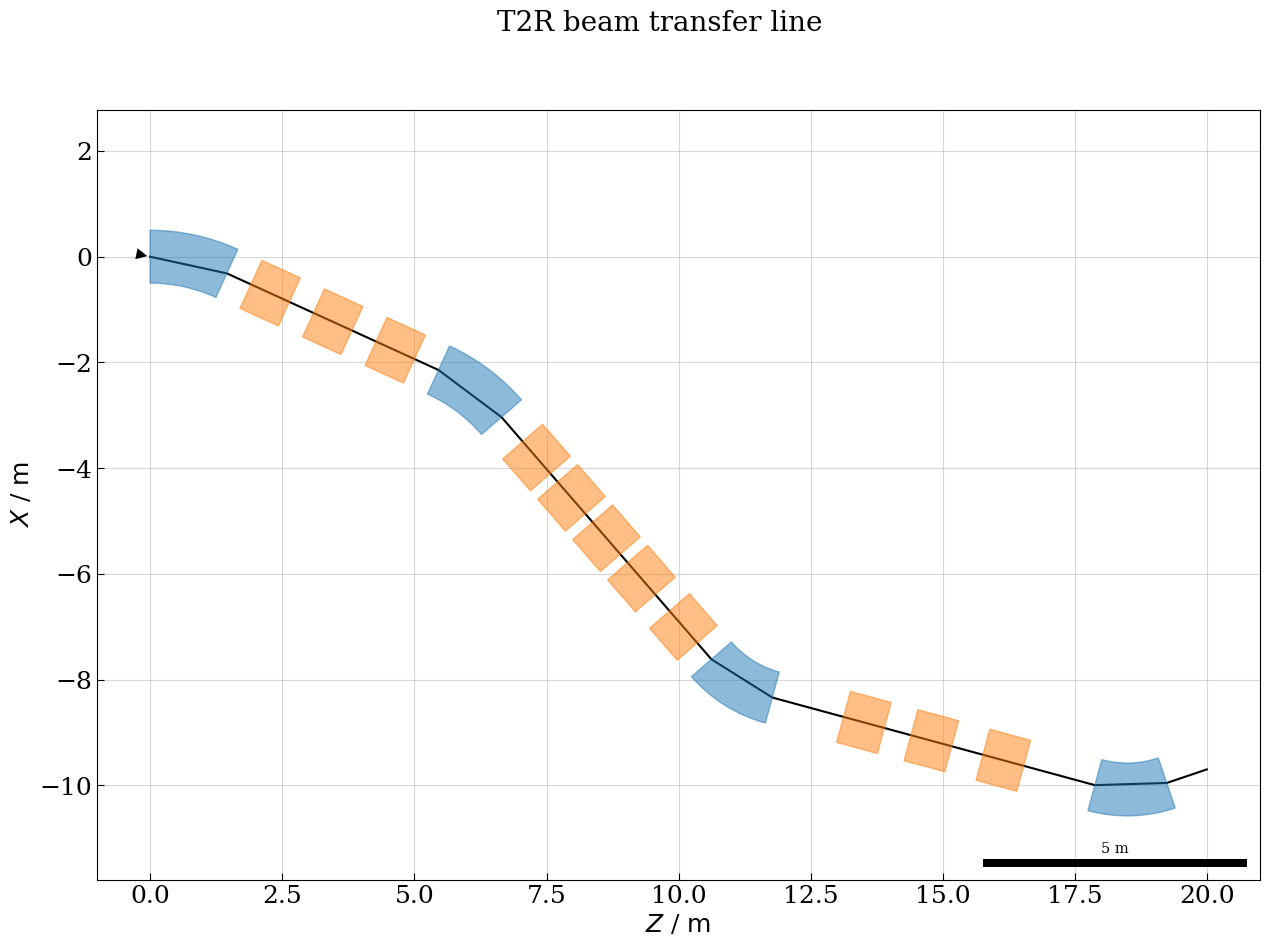

In [177]:
if True :
    import xplt
    plot = xplt.FloorPlot(t2rline.survey(), figsize=(15,10))
    plot.add_scale()
    plot.title('T2R beam transfer line')
    plot.ax.set(ylim=(-10, 1))
    
    _xval = [t2rline_df.iloc[0].Z, t2rline_df.iloc[-1].Z]
 
    # plot2 = xplt.KnlPlot(t2rline, figsize=(7, 3))
    # plot2.ax.set(ylim=(-1, 1));

In [178]:
# --- T2R segments
_segments = [group for _, group in t2rline_elements_df[t2rline_elements_df.element_type.isin(['Bend', 'Quadrupole'])].groupby("theta", sort=False)]
print(len(_segments))
t2r_segments = []
for seg in _segments:
    print(f' --- new segment: angle = {seg.iloc[0].theta:.6f} [rad]')
    print(f' \t elements = {seg.belement.values}')
    _slen = seg.iloc[-1].s_end - seg.iloc[0].s_start 
    print(f'\t  s-length = {_slen:.6f}')

4
 --- new segment: angle = 0.000000 [rad]
 	 elements = ['TLmb1']
	  s-length = 1.500000
 --- new segment: angle = -0.428280 [rad]
 	 elements = ['TLmq1' 'TLmq2' 'TLmq3' 'TLmb2']
	  s-length = 5.400000
 --- new segment: angle = -0.856560 [rad]
 	 elements = ['TLmq4' 'TLmq5' 'TLmq6' 'TLmq7' 'TLmq8' 'TLmb3']
	  s-length = 6.831856
 --- new segment: angle = -0.265205 [rad]
 	 elements = ['TLmq9' 'TLmq10' 'TLmq11' 'TLmb4']
	  s-length = 6.307768


## Build FLUKA Geometry

Model parking area
x = -500 +500     Dx = 10 m
z = -20000 -5000 Dz = 150 m

Injection point to LEnuSTORM ring
x = -10 m from target
z =  15 m from target
angle = to point to a ND module at 250m from the target.

**Note** : for FLUKA the units are converted to cm 

In [179]:
# -- calculate overall angle of LEnuSTORM ring
# Note: 
# - the points are always as {x,z} or {x,y,z} coordinates 
# - units are [m, rad], other units are defined in the name of the variable

t2r_start   = config.t2r_start
t2r_end     = t2r_start + t2rline_df[['X', 'Z']].iloc[-1].to_numpy()
t2r_angle   = np.arcsin(t2rline_df.iloc[-1].X/t2rline_df.iloc[-1].Z)
t2r_length  = np.linalg.norm(t2rline_df.iloc[-1][['X','Z']].to_numpy())

config.update({'t2r_end'        : t2r_end,
               't2r_angle'      : t2r_angle,
               't2r_angle_deg'  : t2r_angle * 180/np.pi,
               't2r_length'     : t2r_length,
               })

lblnd_point = [0, config.trg_to_lblnd]

injection_point         = np.add(t2r_start, config.t2rstart_to_inj)
nsring_angle, nsring_c  =  bsim.line_from_points(injection_point[::-1], lblnd_point[::-1])
nsring_angle_deg        = nsring_angle*180/np.pi
nsring_width            = nustormring_df.X.max() - nustormring_df.X.min() + 2*config.magnet_width
nsring_length           = nustormring_df.Z.max() - nustormring_df.Z.min() - 2*config.magnet_width

config.update({
    'nsring_inj'        : injection_point,
    'nsring_angle'      : nsring_angle,
    'nsring_angle_deg'  : nsring_angle_deg,
    'nsring_width'      : nsring_width,
    'nsring_length'     : nsring_length,
    
})

nsdist_to_dtnl = bsim.distance_point_to_line([nsring_angle, nsring_c], [config.l_decay_tunnel, -config.w_decay_tunnel[0]/2])
config.update({'nsdist_to_dtnl' : nsdist_to_dtnl})

print(f' === Parameters for the T2R line and LEnuSTORM ring ====')
print(f' -  target to ND distance ...................[m] {config.trg_to_lblnd}')
print(f' -  T2R beam transfer line:')
print(f'              start .........................[m] x={t2r_start[0]} z={t2r_start[1]}')
print(f'              end ...........................[m] x={t2r_end[0]} z={t2r_end[1]}')
print(f'              angle .........................{t2r_angle:.5f} [rad], {t2r_angle*180/np.pi:.2f} [deg]')

print(f' -  LEnuSTORM ring:')
print(f'              injection point to target .....[m] x={injection_point[0]} z={injection_point[1]}')
print(f'              angle ......................... {nsring_angle:.5f} [rad] {nsring_angle_deg:.3f} [deg]')
print(f'              tunnel width ..................[m] x={nsring_width:.5f} ')
print(f'              tunnel length .................[m] x={nsring_length:5f} ')

print(f' - Distance to edge of the decay tunnel .....[m] {nsdist_to_dtnl:.5f} ')


 === Parameters for the T2R line and LEnuSTORM ring ====
 -  target to ND distance ...................[m] 320
 -  T2R beam transfer line:
              start .........................[m] x=0 z=2.0
              end ...........................[m] x=-9.698399900672612 z=21.990140928352357
              angle .........................-0.50655 [rad], -29.02 [deg]
 -  LEnuSTORM ring:
              injection point to target .....[m] x=-9.08278251237319 z=25.1539181004073
              angle ......................... 0.03081 [rad] 1.765 [deg]
              tunnel width ..................[m] x=21.44435 
              tunnel length .................[m] x=104.553357 
 - Distance to edge of the decay tunnel .....[m] 11.50389 


In [180]:
# --- Update the T2R and nuSTORM dataframes with the final position and rotation

t2rline_elements_df[['Xp', 'Zp']] = (t2rline_elements_df[['X', 'Z']] + t2r_start)
t2rline_elements_df[['Xp_cm', 'Zp_cm']] = (t2rline_elements_df[['Xp', 'Zp']])*100


# --- Rotation matrix ---
R = np.array([[np.cos(-nsring_angle), -np.sin(-nsring_angle)],
              [np.sin(-nsring_angle),  np.cos(-nsring_angle)]])

rotated = nustormring_elements_df[['X', 'Z']].to_numpy() @ R.T  # matrix multiply
nustormring_elements_df['Xp'] = rotated[:,0] + injection_point[0]
nustormring_elements_df['Zp'] = rotated[:,1] + injection_point[1]
nustormring_elements_df[['Xp_cm', 'Zp_cm']] = (nustormring_elements_df[['Xp', 'Zp']])*100



Text(0.5, 1.0, 'ESSnuSB+ LEnuSTORM Layout')

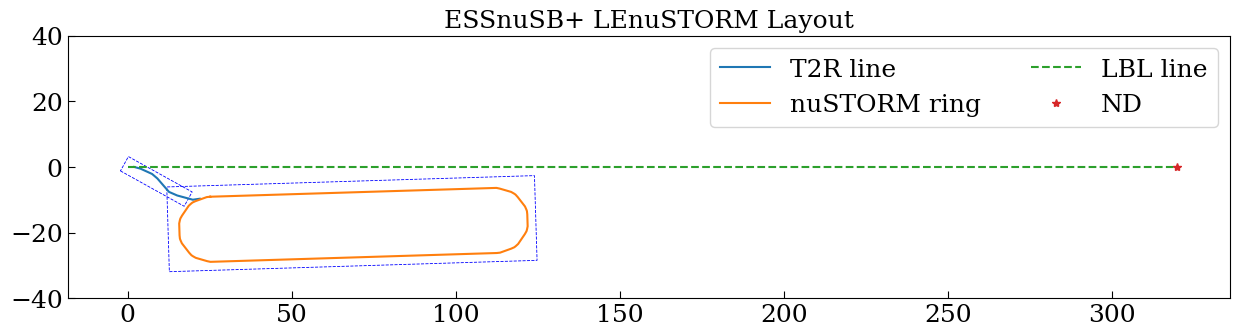

In [181]:
fig,ax = plt.subplots(figsize=(15,10))

# ax.plot(t2rline_elements_df.Z+t2r_start[1], t2rline_elements_df.X+t2r_start[0], label='T2R line')
ax.plot(t2rline_elements_df.Zp, t2rline_elements_df.Xp, label='T2R line')

_twidth = config.w_tline_tunnel
_bottom_left_corner = (-_twidth/2 * np.cos(t2r_angle), _twidth/2 * np.sin(t2r_angle))
_width = _twidth
_length = np.linalg.norm(t2rline_df.iloc[-1][['X','Z']].to_numpy())

rect = patches.Rectangle(_bottom_left_corner, _length, _width,
                         angle =t2r_angle*180/np.pi,
                         facecolor='lightblue',
                         fill=False, edgecolor='blue', linestyle='--', linewidth=0.6)
ax.add_patch(rect)

# ax.plot(_dfy.Zrot, _dfy.Xrot, label='nuSTORM ring')
ax.plot(nustormring_elements_df.Zp, nustormring_elements_df.Xp, label='nuSTORM ring')

_bottom_left_corner = (nustormring_elements_df.Zp.min()-3, nustormring_elements_df.Xp.min()-3)
_width = nustormring_elements_df.X.max() - nustormring_elements_df.X.min()+2*3
_length = nustormring_elements_df.Z.max() - nustormring_elements_df.Z.min() + 2*3

rect = patches.Rectangle(_bottom_left_corner, _length, _width,
                         angle = nsring_angle*180/np.pi, 
                         facecolor='lightblue',
                         fill=False, edgecolor='blue', linestyle='--', linewidth=0.6)
ax.add_patch(rect)

lblline = list(zip([0,0],lblnd_point))
ax.plot(lblline[1], lblline[0], '--', label='LBL line')
ax.plot(config.trg_to_lblnd, 0, '*', label='ND')
ax.legend(ncols=2)
ax.set_ylim(-40, 40)
ax.set_aspect('equal', adjustable='box')
ax.set_title('ESSnuSB+ LEnuSTORM Layout')



### Create magnet models

In [182]:
if True : 
    k0 = 0.428
    slength = 2.21
    angle = 0.428*slength
    print(f'{angle=} {angle*180/np.pi=}')
    rho = 1/k0
    arc = 2*rho*np.sin(angle/2)
    print(f'{k0=}, {angle=}, {rho=}, {arc=}')
    zlength = rho*np.sin(angle)
    b0 = angle*1000*0.7/299.79/slength
    print(f' {zlength=}, {b0=}')


angle=0.9458799999999999 angle*180/np.pi=54.194931925834304
k0=0.428, angle=0.9458799999999999, rho=2.336448598130841, arc=np.float64(2.128530537793036)
 zlength=np.float64(1.8948880225009936), b0=0.9993662230227826


In [183]:
def create_quad_model(name, length, verbose=False):
    ''' Create the model of the quads'''
    aperture = 20
    width = 3.9*aperture
    height = width
    name = name.lower()
    bodies = f'''
RPP     {name}vol {-width/2-0.1} {width/2+0.1} {-width/2-0.1} {width/2+0.1} -0.1 {length+0.1}
RPP     {name}fe {-width/2} {width/2} {-width/2} {width/2} 0 {length}
RCC     {name}vac 0.0 0.0 -0.1 0.0 0.0 {length+0.1} {aperture/2}'''

    regions = f'''
{name.upper()}Env 5
    +{name}vol -{name}fe -{name}vac
{name.upper()}Fe 5
    +{name}fe -{name}vac
{name.upper()}Vac 5
    +{name}vac '''
    
    replica = f'''
RPP     replica {-width/2-0.1} {width/2+0.1} {-width/2-0.1} {width/2+0.1} -0.1 {length+0.1}'''

#    lattice = f'''
#LATTICE, rpregion, , , {name.upper()}Env, , ,transform'''
    lattice = f'''
LATTICE, rpregion, , , latregion, , ,transform'''

    if verbose:
        print(f'''--- QUAD model :
              name ......... {name}
              length ....... {length}
              width ........ {width}
              height ....... {height}
              aperture ..... {aperture}
              ''')


    return bodies, regions, replica, lattice

def create_bend_model(name, slength, k0, verbose=False):
    ''' Create the model of the bends'''
    beam_size = 20
    angle = k0*(slength/100)
    rho = 1/k0*100
    arc = 2*rho*np.sin(angle/2)
    defl = arc*np.sin(angle/2)
    length = rho * np.sin(angle)
    width = 2*(defl + beam_size)*1.2 + 2*30  # here the beam enters the center of the dipole
    height = beam_size + 2*30
    aperx = 2*(defl + beam_size)*1.2
    apery = 1.2 * beam_size
    name = name.lower()
    if verbose:
        print(f'''--- BEND model :
              name ......... {name}
              slength ...... {slength}
              k0 ........... {k0}
              angle ........ {angle}
              rho .......... {rho}
              arc .......... {arc}
              deflection ... {defl}
              length ....... {length}
              width ........ {width}
              height ....... {height}
              aperx ........ {aperx}
              apery ........ {apery}
              ''')
    bodies = f'''
RPP     {name}vol {-width/2-0.1} {width/2+0.1} {-height/2-0.1} {height/2+0.1} -0.1 {length+0.1}
RPP     {name}fe {-width/2} {width/2} {-height/2} {height/2} 0 {length}
RPP     {name}vac {-aperx/2} {aperx/2} {-apery/2} {apery/2} -0.1 {length+0.1}''' 

    regions = f'''
{name.upper()}Env 5
    +{name}vol -{name}fe -{name}vac
{name.upper()}Fe 5
    +{name}fe -{name}vac
{name.upper()}Vac 5
    +{name}vac'''
    
    replica = f'''
RPP     replica {-width/2-0.1} {width/2+0.1} {-width/2-0.1} {width/2+0.1} -0.1 {length+0.1}''' 

#    lattice = f'''
#LATTICE, rpregion, , , {name.upper()}Env, , ,transform'''
    lattice = f'''
LATTICE, rpregion, , , latregion, , ,transform'''


    return bodies, regions, replica, lattice

In [184]:
_aux = t2rline_elements_df.dropna(subset='model')
models_dict = {}
models_dict = _aux.set_index("model").apply(lambda r: 
                {'length' : round(r["length"]*100, 2), 
                 'type'   : r["element_type"], 
                 'kvalue' : r["kvalue"]}, axis=1).to_dict()

_aux = nustormring_elements_df.dropna(subset='model')
models_dict.update(_aux.set_index("model").apply(lambda r: 
                {'length' : round(r["length"]*100, 2), 
                 'type'   : r["element_type"], 
                 'kvalue' : r["kvalue"]}, axis=1).to_dict())

models_dict

{'MB150': {'length': 150.0, 'type': 'Bend', 'kvalue': 0.28552013202450904},
 'QM80': {'length': 80.0, 'type': 'Quadrupole', 'kvalue': 0.3678530140270088},
 'MB138': {'length': 138.08, 'type': 'Bend', 'kvalue': -0.4282801980367636},
 'QM12': {'length': 12.5, 'type': 'Quadrupole', 'kvalue': 2.1941773633721193},
 'QM25': {'length': 25.0, 'type': 'Quadrupole', 'kvalue': -2.089355412989841},
 'MB50': {'length': 50.0, 'type': 'Bend', 'kvalue': 0.6283185307179586}}

In [185]:
mparking = np.array(config.mparking_start)*100
mbodies_cards = []
mregions_cards = []

for mid, mparams in models_dict.items():
    print(f'{mid=}, {mparams=}')
    length, mtype, kvalue = mparams.values()
    
    if mtype == 'Quadrupole':
        bodies, regions, replica, lattice = create_quad_model(mid, length, False)
    elif mtype == 'Bend' :
        bodies, regions, replica, lattice = create_bend_model(mid, length, abs(kvalue), False)
    else:
        continue
    _rotdefi = ''
    bodies = f'$start_translat {mparking[0]} {mparking[1]} {mparking[2]}' + bodies + '\n$end_translat'
    models_dict[mid]['bodies'] = bodies
    mbodies_cards.append(bodies)

    replica = f'$start_translat {mparking[0]} {mparking[1]} {mparking[2]}' + replica + '\n$end_translat'
    models_dict[mid]['replicas'] = replica

    mregions_cards.append(regions)

    _thismodel = {'name': str(mid),
                  'bodies' : bodies,
                  'regions' : regions,
                  'replicas' : replica,
                  'lattice' : lattice,
                  'parking' : mparking.copy(),
                  }
    models_dict[mid].update(_thismodel) 
    
    mparking[2] += -300
# print(f' --- mparking_end = {mparking}')
config.update({'mparking_end': list(mparking/100)})
# print(f' ---- Model Bodies :')
# print(mbodies_cards)

# --- envelop body for the magnet model parking area

mpark_size = (config.mparking_start[2]+3) - config.mparking_end[2]
mbodies_cards.append(f'''
RCC mparki {mparking[0]} {mparking[1]} {mparking[2]} 0 0 {mpark_size*100} {config.mparking_radious*100}
RCC mparko {mparking[0]} {mparking[1]} {mparking[2]-100} 0 0 {mpark_size*100+100} {config.mparking_radious*100+100}
                     ''')
print(f' ---- Model Regions')
mregions_cards.append(f'''
MODELS 5
    +mparko -mparki
MODAIR 5
    +mparki -{" -".join([ s.lower()+"vol" for s in models_dict.keys()])}   
                      ''')
# print(mregions_cards)
print(f' --- Magnet Models dict : ')
pprint.pprint(models_dict) 

mid='MB150', mparams={'length': 150.0, 'type': 'Bend', 'kvalue': 0.28552013202450904}
mid='QM80', mparams={'length': 80.0, 'type': 'Quadrupole', 'kvalue': 0.3678530140270088}
mid='MB138', mparams={'length': 138.08, 'type': 'Bend', 'kvalue': -0.4282801980367636}
mid='QM12', mparams={'length': 12.5, 'type': 'Quadrupole', 'kvalue': 2.1941773633721193}
mid='QM25', mparams={'length': 25.0, 'type': 'Quadrupole', 'kvalue': -2.089355412989841}
mid='MB50', mparams={'length': 50.0, 'type': 'Bend', 'kvalue': 0.6283185307179586}
 ---- Model Regions
 --- Magnet Models dict : 
{'MB138': {'bodies': '$start_translat 0 0 -10700\n'
                     'RPP     mb138vol -101.68247264280984 101.68247264280984 '
                     '-40.1 40.1 -0.1 130.27139444773098\n'
                     'RPP     mb138fe -101.58247264280985 101.58247264280985 '
                     '-40.0 40.0 0 130.171394447731\n'
                     'RPP     mb138vac -71.58247264280985 71.58247264280985 '
                     '-12.

In [186]:
def generate_inp_file(fname, title, cards, verbose=True):
    with open(fname, 'w', newline='\n') as f:
        f.write(f'''*\n*---- {title}  ----\n*\n''')
        for line in cards.split('\n'):
            f.write(line.replace('\r\n', '\n').replace('\r','') + '\n')
    if verbose : 
        print(f' --- created file {fname} with {len(cards.split("\n"))} lines')
    return

In [203]:
generate_inp_file('magnet_models_bodies.inp', 'Magnet models bodies', '\n'.join(mbodies_cards))
generate_inp_file('magnet_models_regions.inp', 'Magnet models regions', '\n'.join(mregions_cards))

 --- created file magnet_models_bodies.inp with 34 lines
 --- created file magnet_models_regions.inp with 48 lines


### Create T2R line elements

In [188]:

t2r_replica_cards = ''
t2r_regions_cards = ' '
t2r_rotdefi_cards = ''
t2r_lattice_cards = ''
t2r_lattice_regions = ''

_x0cm, _z0cm = np.array(config.t2r_start)*100

for el in t2rline_elements_df.itertuples():
    print(el.name, el.belement, el.model)
    if el.model not in models_dict.keys():
        print (f' ---- {el.name=} cannot find model')
        continue
        
    model = models_dict[el.model]
    parking = model['parking']
    replica = model['replicas'].replace('replica', str(el.belement.lower()))
    # print(model, parking, replica)
    
    xc = _x0cm + el.X_cm
    yc = el.Y_cm
    zc = _z0cm + el.Z_cm
    angle = el.theta_deg

    _thisrotdefi = f'''
* - ROTDEFI for element {el.belement} at s={el.s_center}
ROT-DEFI  , 0, , ,{-xc}, {-yc}, {-zc}, t2rtr{el.Index}
ROT-DEFI  , 200, , {angle:.6g}, , , , t2rtr{el.Index} 
ROT-DEFI  , 300, , 0, {parking[0]}, {parking[1]}, {parking[2]}, t2rtr{el.Index} '''

    _thisreplica = f'''
$start_transform -t2rtr{el.Index}
{replica}
$end_transform'''

    t2r_lattice_regions += f' -{el.belement.lower()}'
    
    _thisregion = f'''
{el.belement.upper():8.8} 5
    +{el.belement.lower()}'''

    _thislattice = model['lattice'].replace('transform', f't2rtr{el.Index}').replace('rpregion',el.belement.upper()).replace('latregion',el.belement.upper())
       
    # print(_thisregion)
    # print(_thisrotdefi)
    # print(_thisreplica) 
    # print(_thislattice)
       
    t2r_replica_cards += _thisreplica
    t2r_rotdefi_cards += _thisrotdefi
    t2r_regions_cards += _thisregion
    t2r_lattice_cards += _thislattice

mbtl0.0 TLmb1 MB150
mq_t2r.0 TLmq1 QM80
mq_t2r.1 TLmq2 QM80
mq_t2r.2 TLmq3 QM80
mbtl0.1 TLmb2 MB150
mq_t2r.3 TLmq4 QM80
mq_t2r.4 TLmq5 QM80
mq_t2r.5 TLmq6 QM80
mq_t2r.6 TLmq7 QM80
mq_t2r.7 TLmq8 QM80
end_straight_marker TLen1 nan
 ---- el.name='end_straight_marker' cannot find model
mbtl1.1 TLmb3 MB138
mq_t2r.9 TLmq9 QM80
mq_t2r.10 TLmq10 QM80
mq_t2r.11 TLmq11 QM80
mbtl1.0 TLmb4 MB138
t2rend TLt21 nan
 ---- el.name='t2rend' cannot find model


In [189]:
generate_inp_file('t2rline_elements_rotdefi.inp', 'T2R line element ROT-DEFI', t2r_rotdefi_cards)
generate_inp_file('t2rline_elements_replicas.inp', 'T2R line element replicas', t2r_replica_cards)
generate_inp_file('t2rline_elements_regions.inp', 'T2R line element regions', t2r_regions_cards)
generate_inp_file('t2rline_elements_rattice.inp', 'T2R line element rattice', t2r_lattice_cards)


 --- created file t2rline_elements_rotdefi.inp with 61 lines
 --- created file t2rline_elements_replicas.inp with 76 lines
 --- created file t2rline_elements_regions.inp with 31 lines
 --- created file t2rline_elements_rattice.inp with 16 lines


### Create LEnuSTORM beam elements

In [190]:
# --- rename the bends as MBxx without dot

nustormring_elements_df['belement'] = nustormring_elements_df['belement'].apply(lambda x: x.replace('B.','MB')).values

In [191]:
# -- sanity check if any name >8 characters that FLUKA needs
_dfy = nustormring_elements_df.copy()
_dfy['belement_nlen'] = _dfy['belement'].astype(str).apply(len)
mask = (
    (_dfy["element_type"] != "Drift") &
    (
        (_dfy["belement_nlen"] > 8) |
        (_dfy["belement"].astype(str).str.contains(r"\."))
    )
)
_dfy[mask][['element_type', 'name','belement', 'model']]

,element_type,name,belement,model


In [192]:
if False:
    
    # --- the half length elements
    _cols2use = ['s_fr','element_type','name_fr','name_srv','el_name','model_id', 'model_name']
    lenustorm_df[lenustorm_df['Consecutive_Count'] != 1][frcols2use]
    
    # --- the full length or first elements

    lenustorm_magnetic_elements = lenustorm_df[(lenustorm_df.Consecutive_Count == 1) & (lenustorm_df.element_type != 'Drift')]
    lenustorm_magnetic_elements[frcols2use].tail()

In [193]:
ns_replica_cards = ''
ns_regions_cards = ' '
ns_rotdefi_cards = ''
ns_lattice_cards = ''

ns_lattice_regions = ''


icount = 0
for el in nustormring_elements_df[nustormring_elements_df.element_type != 'Marker'].itertuples():
    if el.model not in models_dict.keys():
        print (f' --- {el.name=} : cannot find a model')
        continue
    model = models_dict[el.model]
    parking = model['parking']
    replica = model['replicas'].replace('replica', str(el.belement.lower()))
    print(f'{el.belement=}, {model=}, {parking=}, {replica=}')
    
    angle = -config.nsring_angle_deg - el.theta_deg + el.angle*180/np.pi/2
    if angle > 180 :
        # print(f' --- frtr{el.Index} ; element:{el.el_name} - {el.name_fr} {angle=:.5f} --> {360-angle:.5f} ({lenustorm_angle_deg=:.5f} {el.theta_deg:.5f} {el.angle*180/np.pi/2=:.5f})')
        angle = 360 - angle
    else:
        angle = -angle
        
    _thisrotdefi = f'''
*! - ROTDEFI for element {el.belement} at s={el.s_center}
ROT-DEFI  , 0, , ,{-el.Xp_cm:.5f}, ,{-el.Zp_cm:.5f}, nstr{el.Index}
ROT-DEFI  , 200, , {angle:.6g}, , , , nstr{el.Index} 
ROT-DEFI  , 300, , 0, {parking[0]}, {parking[1]}, {parking[2]}, nstr{el.Index} '''

    _thisreplica = f'''
$start_transform -nstr{el.Index}
{replica}
$end_transform'''
    
    _thisregion = f'''
{el.belement.upper():8.8} 5
    +{el.belement.lower()}'''

    _thislattice = model['lattice'].replace('transform', f'nstr{el.Index}').replace('rpregion',el.belement.upper()).replace('latregion', el.belement.upper())
    
    # print(_thisregion)
    # print(_thisrotdefi)
    # print(_thisreplica) 
    # print(_thislattice)
       
    ns_replica_cards += _thisreplica
    ns_rotdefi_cards += _thisrotdefi
    ns_regions_cards += _thisregion
    ns_lattice_cards += _thislattice
    
    ns_lattice_regions += f' -{el.belement.lower()}'
    if icount % 10 == 0 :
        ns_lattice_regions += '\n'

el.belement='NSQF1', model={'length': 12.5, 'type': 'Quadrupole', 'kvalue': 2.1941773633721193, 'bodies': '$start_translat 0 0 -11000\nRPP     qm12vol -39.1 39.1 -39.1 39.1 -0.1 12.6\nRPP     qm12fe -39.0 39.0 -39.0 39.0 0 12.5\nRCC     qm12vac 0.0 0.0 -0.1 0.0 0.0 12.6 10.0\n$end_translat', 'replicas': '$start_translat 0 0 -11000\nRPP     replica -39.1 39.1 -39.1 39.1 -0.1 12.6\n$end_translat', 'name': 'QM12', 'regions': '\nQM12Env 5\n    +qm12vol -qm12fe -qm12vac\nQM12Fe 5\n    +qm12fe -qm12vac\nQM12Vac 5\n    +qm12vac ', 'lattice': '\nLATTICE, rpregion, , , latregion, , ,transform', 'parking': array([     0,      0, -11000])}, parking=array([     0,      0, -11000]), replica='$start_translat 0 0 -11000\nRPP     nsqf1 -39.1 39.1 -39.1 39.1 -0.1 12.6\n$end_translat'
el.belement='NSQD1', model={'length': 25.0, 'type': 'Quadrupole', 'kvalue': -2.089355412989841, 'bodies': '$start_translat 0 0 -11300\nRPP     qm25vol -39.1 39.1 -39.1 39.1 -0.1 25.1\nRPP     qm25fe -39.0 39.0 -39.0 39.0 0

In [194]:
generate_inp_file('lenustorm_elements_rotdefi.inp', 'LEnuSTORM element ROT-DEFI', ns_rotdefi_cards)
generate_inp_file('lenustorm_elements_replicas.inp', 'LEnuSTORM element replicas', ns_replica_cards)
generate_inp_file('lenustorm_elements_regions.inp', 'LEnuSTORM element regions', ns_regions_cards)
generate_inp_file('lenustorm_elements_lattice.inp', 'LEnuSTORM element lattice', ns_lattice_cards)


 --- created file lenustorm_elements_rotdefi.inp with 1217 lines
 --- created file lenustorm_elements_replicas.inp with 1521 lines
 --- created file lenustorm_elements_regions.inp with 609 lines
 --- created file lenustorm_elements_lattice.inp with 305 lines


### Create target and Horn Assembly


In [201]:
def create_target_and_horn(config=config):
    _bodies = ''
    _regions = ''

    _bodies += f'''
RPP thbox     {getcoord(config.thbox_x, 0)} {getcoord(config.thbox_y, 0)} {getcoord(config.thbox_z, 0)}
RCC target  0 0 0 0 0 {config.target_len*100} {config.target_radious*100}
    '''
    _regions += f'''
THBOX  5 
    +thbox -target
TARGET 5
    +target
    '''
    return _bodies, _regions

In [202]:
th_bodies_cards, th_regions_cards = create_target_and_horn(config)

generate_inp_file('thbox_bodies.inp', 'Target & Horn Assembly', th_bodies_cards)
generate_inp_file('thbox_regions.inp', 'Target & Horn Assembly', th_regions_cards)


 --- created file thbox_bodies.inp with 4 lines
 --- created file thbox_regions.inp with 6 lines


### Create global volumes 

- overall world and void regions
- target cavern
- tunnels for T2R and nuSTORM ring

In [197]:
if False : 
    bsim_parameters
    print(lenustorm_df.Z.min(), tt_inj_point[1], bsim_parameters["w_ring_tunnel"])
    print(tt_inj_point[1]+lenustorm_df.Z.min()-bsim_parameters["w_ring_tunnel"]/2)

    print(tt_length)


    print(bsim_parameters["w_ring_tunnel"]*100, tt_inj_point[1]*100,  lenustorm_df.Z.min()*100)
    print(-bsim_parameters["w_ring_tunnel"]*100 + tt_inj_point[1]*100 + lenustorm_df.Z.min()*100)
    bsim_parameters
    pc_primary = np.sqrt(2.5*(2.5+2*0.9382))
    primary_d1_angle = tt_bend_angle*0.7/pc_primary
    print(f' --- primary beam momentum ... {pc_primary:.5g} [GeV]')
    print(f' --- angle in Bend1 .......... {primary_d1_angle:.5g} [deg]')
    bsim_parameters
    bsim_parameters


In [198]:
getcoord(config.w_target_cavern, config.d_shield)

'-750.0 750.0'

In [ ]:
glob_bodies = ''
glob_regions = ''
glob_rotdefi = ''

# --- Target Cavern and Decay pipea

tcc_xo = getcoord(config.w_target_cavern, config.d_shield)
tcc_yo = getcoord(config.h_target_cavern, config.d_shield)
tcc_zo = getcoord(config.z_target_cavern, 0)
tcc_xi = getcoord(config.w_target_cavern, 0)
tcc_yi = getcoord(config.h_target_cavern, 0)
tcc_zi = getcoord(config.z_target_cavern, 0)

tdec_xo = getcoord(config.w_decay_tunnel, config.d_shield)
tdec_yo = getcoord(config.h_decay_tunnel, config.d_shield)
tdec_zo = getcoord([config.z_target_cavern[1]-1, config.z_target_cavern[1]+config.l_decay_tunnel+1+config.d_shield], 0)
tdec_xi = getcoord(config.w_decay_tunnel, 0)
tdec_yi = getcoord(config.h_decay_tunnel, 0)
tdec_zi = getcoord([config.z_target_cavern[1]-1, config.z_target_cavern[1]+config.l_decay_tunnel+1], 0)

glob_bodies += f'''
SPH blkbody    0 0 0 100000
SPH void       0 0 0 90000
*
* --- target cavern
RPP tcco     {tcc_xo} {tcc_yo} {tcc_zo}
RPP tcci     {tcc_xi} {tcc_yi} {tcc_zi}
*
* --- decay tunnel
RPP tdeco     {tdec_xo} {tdec_yo} {tdec_zo}
RPP tdeci     {tdec_xi} {tdec_yi} {tdec_zi}
'''

# --- T2R tunnel

glob_rotdefi += f'''
ROT-DEFI , 200, {config.t2r_angle:.6g}, , , , t2rtun
ROT-DEFI , 300, 0, 0, 0, {t2r_start*100}, t2rtun
'''
t2rt_xo = getcoord([-config.w_tline_tunnel/2, config.w_tline_tunnel/2], config.d_shield)
t2rt_yo = getcoord([-config.h_tline_tunnel/2, config.h_tline_tunnel/2], config.d_shield)
t2rt_zo = getcoord([0, config.t2r_length], 0)
t2rt_xi = getcoord([-config.w_tline_tunnel/2, config.w_tline_tunnel/2], 0)
t2rt_yi = getcoord([-config.h_tline_tunnel/2, config.h_tline_tunnel/2], 0)
t2rt_zi = getcoord([0, config.t2r_length], 0)

glob_bodies +=f'''
*
* --- T2R tunnel
$start_transform t2rtun
RPP t2rto     {t2rt_xo} {t2rt_yo} {t2rt_zo}
RPP t2rti     {t2rt_xi} {t2rt_yi} {t2rt_zi}
$end_transform
'''

# --- leNUSTORM tunnel

glob_rotdefi += f'''
ROT-DEFI , 200, {config.nsring_angle:.6g}, , , , nsring
ROT-DEFI , 300, 0, {config.nsring_inj[0]*100}, 0, {config.nsring_inj[1]*100}, nsring
'''
nsring_xo = getcoord([-config.w_ring_tunnel/2, config.w_ring_tunnel/2], config.d_shield)
nsring_yo = getcoord([-config.h_ring_tunnel/2, config.h_ring_tunnel/2], config.d_shield)
nsring_zo = getcoord([-config.d_shield, config.nsring_length+config.d_shield], 0)
nsring_xi = getcoord([-config.w_ring_tunnel/2, config.w_ring_tunnel/2], 0)
nsring_yi = getcoord([-config.h_ring_tunnel/2, config.h_ring_tunnel/2], 0)
nsring_zi = getcoord([0, config.nsring_length], 0)

glob_bodies +=f'''
*
* --- T2R tunnel
$start_transform t2rtun
RPP nsto     {nsring_xo} {nsring_yo} {nsring_zo}
RPP nsti     {nsring_xi} {nsring_yi} {nsring_zi}
$end_transform
'''

# --- Global regions

glob_regions += f'''
BLKBODY 5
  +blkbody -void
VOID    5
  +void -tcco -tdeco -mparko -nsto -t2rto
SHIELD  5
  (+tcco -tcci)
  | (+tdeco -tdeci)
HEVOL  5
  +tcci
  | +tdeci
'''

print(glob_bodies)
print(glob_rotdefi)
print(glob_regions)



SPH blkbody    0 0 0 100000
SPH void       0 0 0 90000
*
* --- target cavern
RPP tcco     -750.0 750.0 -750.0 750.0 -100 400
RPP tcci     -350.0 350.0 -350.0 350.0 -100 400
*
* --- decay tunnel
RPP tdeco     -1100.0 1100.0 -1050.0 1050.0 300.0 6900.0
RPP tdeci     -700 700 -650.0 650.0 300 6500

*
* --- T2R tunnel
$start_transform t2rtun
RPP t2rto     -650.0 650.0 -600.0 600.0 0.0 2221.8566447202543
RPP t2rti     -250.0 250.0 -200.0 200.0 0.0 2221.8566447202543
$end_transform

*
* --- T2R tunnel
$start_transform t2rtun
RPP nsto     -500.0 500.0 -600.0 600.0 -400.0 10855.335691748995
RPP nsti     -100.0 100.0 -200.0 200.0 0.0 10455.335691748995
$end_transform


ROT-DEFI , 200, -0.506545, , , , t2rtun
ROT-DEFI , 300, 0, 0, 0, [0, 2.0, 0, 2.0, 0, 2.0, 0, 2.0, 0, 2.0, 0, 2.0, 0, 2.0, 0, 2.0, 0, 2.0, 0, 2.0, 0, 2.0, 0, 2.0, 0, 2.0, 0, 2.0, 0, 2.0, 0, 2.0, 0, 2.0, 0, 2.0, 0, 2.0, 0, 2.0, 0, 2.0, 0, 2.0, 0, 2.0, 0, 2.0, 0, 2.0, 0, 2.0, 0, 2.0, 0, 2.0, 0, 2.0, 0, 2.0, 0, 2.0, 0, 2.0, 0, 2.0, 

In [200]:
generate_inp_file('glob_bodies.inp', 'General bodies', glob_bodies)
generate_inp_file('glob_regions.inp', 'General regions', glob_regions)
generate_inp_file('glob_rotdefi.inp', 'General ROT-DEFI', glob_rotdefi)

 

 --- created file glob_bodies.inp with 26 lines
 --- created file glob_regions.inp with 12 lines
 --- created file glob_rotdefi.inp with 7 lines


## End of code here